# Tech Challenge Fiap - Fase 1

## Case NPS Preditivo
Prever satisfação do cliente (NPS) antes da aplicação da pesquisa.

## Fase 4 - Data Modeling

Na Fase 4 do CRISP-DM construímos e avaliamos o modelo preditivo. O objetivo é responder ao Objetivo Analítico 2 definido na fase 1, prever se um cliente será Detrator antes da pesquisa NPS.

In [354]:
# Carregando as bibliotecas da Fase 3 - Data Preparation

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Escolha do Modelo de Classificação 

Vamos começar por Regressão Logistica e evoluir para Random Forest posteriormente.  
Regressão Logística serve como baseline, é o ponto de partida. Se o Random Forest não superar a Regressão Logística, algo está errado.    
Random Forest é o modelo principal, mais robusto, lida melhor com o desbalanceamento do dataset e vai provavelmente atingir as métricas que definimos na Questão 1.  

### Modelo Classificação - Regressão Logistica  

Regressão Logística prevê uma probabilidade entre 0 e 1, que é convertida em uma classe.  

Prever se um cliente será Detrator → Sim ou Não  
Prever se um cliente será Detrator → 1 ou 0

Nosso Target é nps_detrator, só tem dois valores possiveis: 0 ou 1. 

"Esse cliente vai ser Detrator?"  
Essa é a pergunta que o modelo deve prever.

A Regressão Logística resolve isso aplicando uma função matemática chamada sigmoide que comprime qualquer valor entre 0 e 1, representando a probabilidade do cliente ser Detrator ou não. 

In [355]:
# Algoritmo do modelo
from sklearn.linear_model import LogisticRegression
# Padronização features
from sklearn.preprocessing import StandardScaler
# Métricas
from sklearn.metrics import classification_report, roc_curve, auc, roc_auc_score

# 1. Carregando dados
X_train = pd.read_csv('X_train.csv') #feature de treino
X_test = pd.read_csv('X_test.csv') #feature de teste
y_train = pd.read_csv('y_train.csv') #target de treino
y_test = pd.read_csv('y_test.csv') #target de teste

In [356]:
# 2. Padronização (crucial para Regressão Logística)
# Como 'order_value' está em centenas e 'complaints_count' em unidades, 
# o scaler coloca todos na mesma escala.
scaler = StandardScaler() #Cria padronizador
X_train_scaled = scaler.fit_transform(X_train) #aprende escala no treino e transforma
X_test_scaled = scaler.transform(X_test) #usa escala aprendida para transformar o teste 

#  fit_transform só no treino 
# transform no teste, senão fizesse isso, estariamos "contaminando" o modelo com informações do futuro.

In [357]:
# 3. Treinando o Modelo (Fit)
# O Target é a coluna 'nps_detrator' (1 = Detrator, 0 = Promotor/Neutro)
# O class_weight="balanced" ajuda a lidar com desequilíbrio entre classes

# class_weight="balanced" → compensa o desbalanceamento 74% Detratores / 26% Não Detratores
# random_state=42 → garante reprodutibilidade
modelo = LogisticRegression(class_weight= "balanced", random_state= 42)

# fit → o modelo aprende os padrões dos dados de treino
# values.ravel() → converte o dataframe y_train em array 1D que o sklearn espera
modelo.fit(X_train_scaled, y_train.values.ravel())

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [358]:
# 4. Gerar Previsões de Classe e Probabilidades
y_pred = modelo.predict(X_test_scaled) #Preve a classe (0 ou 1) para cada cliente

#Preve a probabilidade de ser Detrator (classe 1)
y_probs = modelo.predict_proba(X_test_scaled)[:, 1] # [:, 1] → pega apenas a coluna da classe 1 (Detrator)



In [359]:
# 5. Exibir Métricas de Classificação
print("--- Relatório de Classificação ---")
# Precision, Recall, f1 para cada classe 
print(classification_report(y_test, y_pred))

#(1 = Detrator, 0 = Promotor/Neutro)

--- Relatório de Classificação ---
              precision    recall  f1-score   support

           0       0.61      0.79      0.69       137
           1       0.91      0.81      0.86       363

    accuracy                           0.80       500
   macro avg       0.76      0.80      0.77       500
weighted avg       0.83      0.80      0.81       500



**Recall** - "De todos os Detratores reais, quantos o modelo encontrou?"  
Recall de 81% → O modelo identifica corretamente 81% dos Detratores reais. No conjunto de teste, isso equivale a 294 de 363 clientes. 69 clientes classifica como "Promotor/Neutro".

**Precision**  - "De todos que o modelo disse ser Detrator, quantos realmente eram?"  

Precision de 91% → quando o modelo diz que um cliente é Detrator, ele acerta 91% das vezes. 

De todos os 323 clientes que o modelo classificou como Detrator, 91% (294) realmente eram Detratores. Os outros 9% (29) eram falsos alarmes. 

Alta Precision = Poucos alarmes falsos (cliente que já seria Promotor).


| | Previsto Não Detrator | Previsto Detrator | **Total Real** |
|---|---|---|---|
| **Real Não Detrator** | 108 | 29 | **137** |
| **Real Detrator** | 69 | 294 | **363** |
| **Total Previsto** | **177** | **323** | **500** |


**F1-Score** - "Média equilibrada entre Precision e Recall"  
F1 de 0.86 → Ótimo equilíbrio entre Precision e Recall.   

| F1 | Interpretação |
|---|---|
| < 0.50 | Modelo ruim |
| 0.50 - 0.70 | Modelo razoável |
| 0.70 - 0.85 | Modelo bom |
| 0.85 - 1.00 | Modelo excelente |


O modelo tem um equilíbrio de 86% entre sua capacidade de encontrar Detratores reais (Recall 81%) e sua precisão ao apontar um Detrator (Precision 91%).  

<br>

**Classe 0 — Não Detrator**  

| Métrica | Valor |
|---|---|
| Precision | 0.61 |
| Recall | 0.79 |
| F1-Score | 0.69 |
| Support | 137 |  

Recall - "De todos os Não Detratores reais (137), quantos o modelo achou?"  

De 137 clientes que realmente não eram Detratores, o modelo identificou corretamente 108 (79%). Os outros 29 foram classificados erroneamente como Detratores.  

Precision - "De todos que o modelo disse Não Detrator (108 (classe 0) +69 (classe 1) =177), quantos eram reais?"  

De todos os clientes que o modelo disse "Não Detrator", apenas 61% (108/177) realmente não eram. Os outros 39% eram Detratores que o modelo classificou errado.  

**Isso é perigoso para o negócio?** 

Essas 69 pessoas são Detratores que o modelo deixou escapar, classificou como satisfeitos quando na verdade estão insatisfeitos. A empresa não vai agir preventivamente com elas.  

Isso está diretamente ligado ao Recall da Classe 1, quanto mais Detratores escapam, menor o Recall. É exatamente por isso que o Recall é a nossa métrica prioritária no projeto.   

<br>

**Classe 1 — Detrator**

| Métrica | Valor |
|---|---|
| Precision | 0.91 |
| Recall | 0.81 |
| F1-Score | 0.86 |
| Support | 363 |  

Recall - "De todos os Detratores reais (363), quantos o modelo achou?"  


De 363 clientes que realmente eram Detratores, o modelo identificou corretamente 294 (81%). Os outros 69 passaram como "Não Detrator". 

Precision - "De todos que o modelo disse Detrator (29 (classe 0) +294 (classe 1) = 323), quantos eram reais?"  

O modelo previu 323 clientes como Detratores (294 recall + 29 que o modelo classificou errado). Desses 323, 294 (91%) eram realmente Detratores e 29 (9%) eram falsos alarmes.  


**Isso é perigoso para o negócio?**   

Os 69 clientes na classe 1 classificados erroneamente como "Não Detratores" são o erro mais custoso do modelo. A empresa não vai agir preventivamente com esses clientes, eles vão responder a pesquisa NPS com nota ≤ 6 e a insatisfação só será descoberta depois, quando já é tarde para agir.  

**Comparando os dois erros:**  

29 falsos alarmes (Classe 0) → empresa aciona preventivamente no cliente satisfeito → custo baixo  
69 Detratores escaparam (Classe 1) → empresa perde a chance de agir → custo alto  

É exatamente por isso que o Recall é a métrica prioritária: Minimizar os 69 é mais importante do que minimizar os 29.  


<br>

#### Matriz de confusão  

| | Previsto Não Detrator | Previsto Detrator |
|---|---|---|
| **Real Não Detrator** | 108 | 29 |
| **Real Detrator** | 69 | 294 |  

<br>

De 137 Não Detratores reais → modelo acertou 108 e errou 29  
De 363 Detratores reais → modelo acertou 294 e errou 69   
  
- O 29 está na célula "Real Não Detrator + Previsto Detrator", ou seja, clientes que realmente não eram Detratores mas o modelo classificou como Detratores.  
- O 69 está na célula "Real Detrator + Previsto Não Detrator", ou seja, clientes que realmente eram Detratores mas o modelo classificou como Não Detratores.    

Esses números vieram do Recall da Classe 0 e Classe 1, respectivamente.
<br> 




In [360]:
# 6. Calcular e exibir AUC-ROC
# calcula a área sob a curva ROC — quanto mais perto de 1, melhor
auc_valor = roc_auc_score(y_test, y_probs)
print(f"AUC-ROC Score: {auc_valor:.4f}")


AUC-ROC Score: 0.8739


**AUC-ROC**  
Capacidade geral do modelo de separar Detratores de Não Detratores.  

Varia de 0 a 1: Quanto mais perto de 1, melhor.  
0.5 = modelo aleatório (linha cinza do gráfico)    
1.0 = modelo perfeito  

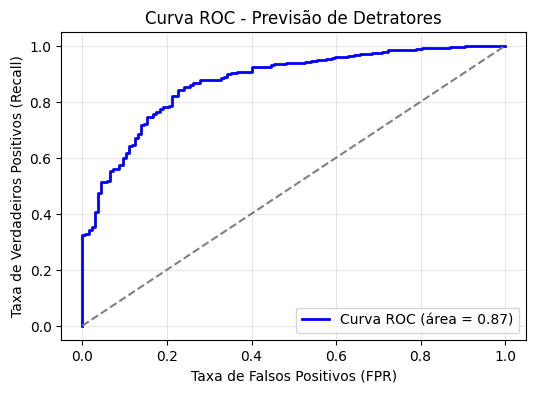

In [361]:
# 7. Gerar e Salvar o Gráfico da Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
# fpr = taxa de falsos positivos (eixo X)
# tpr = taxa de verdadeiros positivos / Recall (eixo Y)
# thresholds = os limiares de decisão

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Curva ROC (área = {auc_valor:.2f})') #curva do modelo
plt.plot([0, 1], [0, 1], color='gray', linestyle='--') # Linha de base
# Se a curva estiver acima da linha, o modelo é melhor que o acaso

plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (Recall)')
plt.title('Curva ROC - Previsão de Detratores')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

**Interpretação do gráfico AuC-ROC**

A linha cinza pontilhada representa um modelo aleatório, equivale a jogar uma moeda.   
AUC = 0.50. Se o seu modelo estivesse nessa linha, seria inútil.  


A curva azul representa o seu modelo.   
Quanto mais a curva se afasta da linha cinza em direção ao canto superior esquerdo, melhor o modelo. 

| AUC | Interpretação |
|---|---|
| 0.50 | Modelo aleatório |
| 0.60 - 0.80 | Modelo razoável |
| 0.80 - 0.90 | Modelo bom |
| 0.90 - 1.00 | Modelo excelente |  

**Checkpoint Métricas**

Verificando se todas as métricas da fase 1 - Business Understanding foram atingidas. 

| Métrica | Meta | Resultado | Status |
|---|---|---|---|
| Recall | ≥ 75% | 81% | ✅ |
| AUC-ROC | ≥ 0.80 | 0.87 | ✅ |
| F1-Score | ≥ 0.70 | 0.86 | ✅ |
| Precision | ≥ 60% | 91% | ✅ |

Para demonstrar o modelo em produção, fazemos uma previsão para o primeiro cliente do conjunto de teste. O modelo retorna tanto a classe prevista (Detrator ou Não Detrator) quanto a probabilidade associada.

In [362]:
# 8. Exemplo de Previsão Individual
# pega o primeiro cliente do teste e formata para o sklearn
primeiro_cliente = X_test_scaled[0].reshape(1, -1)
previsao = modelo.predict(primeiro_cliente) #classe prevista
probabilidade = modelo.predict_proba(primeiro_cliente) #probabilidade

print(f"\nPrevisão para o primeiro cliente: {'Detrator' if previsao[0] == 1 else 'Não Detrator'}")
print(f"Probabilidade: {probabilidade[0][1]:.2%} de ser detrator.")


Previsão para o primeiro cliente: Detrator
Probabilidade: 56.31% de ser detrator.


O modelo classificou esse cliente como Detrator com 56.31% de probabilidade. Numa aplicação real, a empresa poderia definir um threshold (ponto de corte), por exemplo, acionar ação preventiva para qualquer cliente com probabilidade acima de 50%.

- Threshold menor (ex: 40%) → captura mais Detratores → Recall maior → mais falsos positivos  
- Threshold maior (ex: 60%) → mais conservador → Precision maior → mais Detratores escapam

Para o objetivo de negócio de maximizar a captura de Detratores, um threshold menor que 50% seria mais adequado, aumentando o Recall ao custo de mais falsos positivos. Essa decisão deve ser validada com a equipe de negócio considerando a capacidade operacional de atendimento preventivo.

| Threshold | Recall | Precision | Consequência |
|---|---|---|---|
| 30% | Alto | Baixo | Captura mais Detratores, mas aciona muitos clientes satisfeitos |
| 50% | Médio | Médio | Padrão do sklearn: Equilíbrado |
| 70% | Baixo | Alto | Poucos falsos alarmes, mas muitos Detratores escapam |

### **Cross-Validation**

In [363]:
from sklearn.model_selection import cross_val_score
import pandas as pd

X_clf = pd.read_csv('X_train.csv')
y_clf = pd.read_csv('y_train.csv').squeeze()

scores = cross_val_score(modelo, X_clf, y_clf, cv=5, scoring='recall')
print(f"Recall médio (CV=5): {scores.mean():.2f} ± {scores.std():.2f}")

Recall médio (CV=5): 0.79 ± 0.02


/Users/vinicius/Documents/workspace/tech_challenge/tech-challenge-env/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/vinicius/Documents/workspace/tech_challenge/tech-challenge-env/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also w

Em 5 validações diferentes, o modelo manteve Recall médio de 79% com variação de apenas ±2%, demonstrando consistência e ausência de overfitting.

| Cross-Validation | Resultado |
|---|---|
| Recall médio (CV=5) | 0.79 |
| Desvio padrão | ± 0.02 |
| Interpretação | Modelo consistente — baixa variação entre os folds |

### Modelo Classificação - Random Forest

É um método matemático que aprende padrões nos dados de treino e usa esses padrões para prever a classe de novos dados.  

**Aprende com:** 2000 pedidos que já têm nps_detrator conhecido  
**Prevê:** se um pedido novo resultará em Detrator (1) ou Não Detrator (0)  

```
complaints_count > 3?
├── SIM → delivery_delay_days > 2?
│         ├── SIM → DETRATOR
│         └── NÃO → DETRATOR
└── NÃO → resolution_time_days > 5?
          ├── SIM → DETRATOR
          └── NÃO → NÃO DETRATOR
```

O modelo aprende quais perguntas fazer e em que ordem para melhor separar Detratores de Não Detratores.

In [364]:
# Algoritmo do modelo
from sklearn.ensemble import RandomForestClassifier
# Métricas
from sklearn.metrics import classification_report, roc_curve, auc, roc_auc_score

# 1. Carregando dados
X_train = pd.read_csv('X_train.csv') #feature de treino
X_test = pd.read_csv('X_test.csv') #feature de teste
y_train = pd.read_csv('y_train.csv') #target de treino
y_test = pd.read_csv('y_test.csv') #target de teste

In [365]:
# 2. Treinando o Modelo (Fit)
# O Target é a coluna 'nps_detrator' (1 = Detrator, 0 = Promotor/Neutro)
# O class_weight="balanced" ajuda a lidar com desequilíbrio entre classes

# class_weight="balanced" → compensa o desbalanceamento 74% Detratores / 26% Não Detratores
# random_state=42 → garante reprodutibilidade
modelo = RandomForestClassifier(class_weight= "balanced", random_state= 42)

# fit → o modelo aprende os padrões dos dados de treino
# values.ravel() → converte o dataframe y_train em array 1D que o sklearn espera
modelo.fit(X_train, y_train.values.ravel())

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [366]:
# 3. Gerar Previsões de Classe e Probabilidades
y_pred = modelo.predict(X_test) #Preve a classe (0 ou 1) para cada cliente

#Preve a probabilidade de ser Detrator (classe 1)
y_probs = modelo.predict_proba(X_test)[:, 1] # [:, 1] → pega apenas a coluna da classe 1 (Detrator)



In [367]:
# 4. Gerar Previsões de Classe e Probabilidades
y_pred = modelo.predict(X_test) #Preve a classe (0 ou 1) para cada cliente

#Preve a probabilidade de ser Detrator (classe 1)
y_probs = modelo.predict_proba(X_test)[:, 1] # [:, 1] → pega apenas a coluna da classe 1 (Detrator)



In [368]:
# 5. Exibir Métricas de Classificação

print("--- Relatório de Classificação ---")

# Precision, Recall, f1 para cada classe 

print(classification_report(y_test, y_pred))

--- Relatório de Classificação ---
              precision    recall  f1-score   support

           0       0.77      0.47      0.58       137
           1       0.82      0.95      0.88       363

    accuracy                           0.82       500
   macro avg       0.80      0.71      0.73       500
weighted avg       0.81      0.82      0.80       500



**Classe 0 — Não Detrator**

Recall caiu para 47%, o modelo erra mais nos Não Detratores em troca de capturar mais Detratores.  

De 137 clientes que realmente não eram Detratores, o modelo identificou corretamente apenas 64 (47%). Os outros 73 foram classificados erroneamente como Detratores, ou seja, falsos alarmes (clientes que já seriam Promotores/Neutros).

**Por que isso acontece?**   
Ao maximizar o Recall dos Detratores (95%), o Random Forest se torna mais agressivo, classifica mais clientes como Detrator para não deixar nenhum escapar. O custo disso é errar mais nos Não Detratores.  

Comparando com a Regressão Logística que acertou 108 (79%) dos Não Detratores, o Random Forest é claramente pior nessa classe. Porém, como definimos nossa métrica principal (Recall) na fase 1 (Business Understanding), esse trade-off aceitável, preferimos acionar 73 clientes satisfeitos desnecessariamente a deixar 18 Detratores escaparem sem ação.  

Os 18 Detratores que escaparam podem ser minimizados ajustando o threshold para abaixo de 50%. Essa decisão deve ser validada com a equipe de negócio considerando a capacidade operacional de atendimento preventivo.

In [369]:
# 6. Calcular e exibir AUC-ROC

# calcula a área sob a curva ROC — quanto mais perto de 1, melhor

auc_valor = roc_auc_score(y_test, y_probs)

print(f"AUC-ROC Score: {auc_valor:.4f}")



AUC-ROC Score: 0.8488


O Random Forest atingiu AUC-ROC de 0.85, classificado como modelo bom. Embora ligeiramente inferior à Regressão Logística (0.87), o Random Forest compensa com Recall significativamente superior (95% vs 81%), que é a métrica prioritária para o objetivo de negócio.

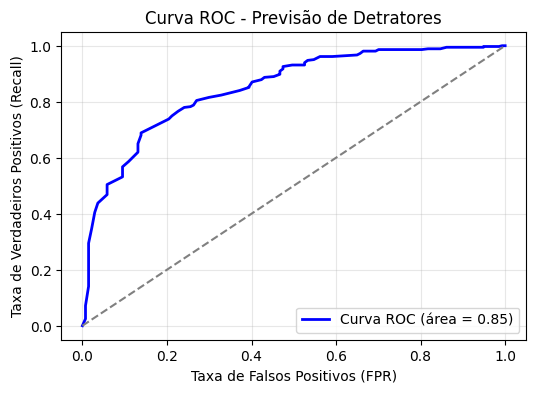

In [370]:
# 7. Gerar e Salvar o Gráfico da Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
# fpr = taxa de falsos positivos (eixo X)
# tpr = taxa de verdadeiros positivos / Recall (eixo Y)
# thresholds = os limiares de decisão

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Curva ROC (área = {auc_valor:.2f})') #curva do modelo
plt.plot([0, 1], [0, 1], color='gray', linestyle='--') # Linha de base
# Se a curva estiver acima da linha, o modelo é melhor que o acaso

plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (Recall)')
plt.title('Curva ROC - Previsão de Detratores')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

**Checkpoint Métricas**

Verificando se todas as métricas da fase 1 - Business Understanding foram atingidas. 


| Métrica | Meta | Resultado | Status |
|---|---|---|---|
| Recall | ≥ 75% | 95% | ✅ |
| AUC-ROC | ≥ 0.80 | 0.85 | ✅ |
| F1-Score | ≥ 0.70 | 0.88 | ✅ |
| Precision | ≥ 60% | 82% | ✅ |

Para demonstrar o modelo em produção, simulamos uma previsão individual para o primeiro cliente do conjunto de teste. Na prática, assim que um cliente conclui a jornada de compra, o modelo recebe os dados operacionais e retorna imediatamente a classe prevista e a probabilidade associada, permitindo que a equipe de CRM aja preventivamente antes da pesquisa NPS.

In [371]:
# 8. Exemplo de Previsão Individual
# pega o primeiro cliente do teste e formata para o sklearn
primeiro_cliente = X_test.iloc[0].values.reshape(1, -1)
previsao = modelo.predict(primeiro_cliente) #classe prevista
probabilidade = modelo.predict_proba(primeiro_cliente) #probabilidade

print(f"\nPrevisão para o primeiro cliente: {'Detrator' if previsao[0] == 1 else 'Não Detrator'}")
print(f"Probabilidade: {probabilidade[0][1]:.2%} de ser detrator.")


Previsão para o primeiro cliente: Detrator
Probabilidade: 89.00% de ser detrator.


/Users/vinicius/Documents/workspace/tech_challenge/tech-challenge-env/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/vinicius/Documents/workspace/tech_challenge/tech-challenge-env/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


O modelo classificou esse cliente como Detrator com 89% de probabilidade, alto grau de certeza. Numa aplicação real, esse cliente seria imediatamente acionado pela equipe de atendimento com uma ação preventiva, como um contato proativo ou cupom de desconto.
A probabilidade é mais valiosa que a classe sozinha, ela permite priorizar ações. Um cliente com 89% de probabilidade merece atenção imediata, enquanto um com 51% pode receber uma ação mais moderada.

### **Cross-Validation**

Para garantir que o modelo não está apenas se saindo bem em um split específico, aplicamos Cross-Validation com 5 folds. O modelo é treinado e testado 5 vezes em partes diferentes dos dados.

In [372]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

# Recriando o modelo para o Cross-Validation
modelo_rf_cv = RandomForestClassifier(class_weight='balanced', random_state=42)

X_clf = pd.read_csv('X_train.csv')
y_clf = pd.read_csv('y_train.csv').squeeze()

scores = cross_val_score(modelo_rf_cv, X_clf, y_clf, cv=5, scoring='recall')
print(f"Recall médio (CV=5): {scores.mean():.2f} ± {scores.std():.2f}")

Recall médio (CV=5): 0.94 ± 0.01


O Cross-Validation com 5 folds confirma a robustez do modelo. Em 5 avaliações diferentes, o Random Forest manteve Recall médio de 94% com variação de apenas ±1%, praticamente constante entre os folds.
Isso confirma que o resultado de 95% obtido no conjunto de teste não foi sorte, o modelo é genuinamente capaz de identificar Detratores de forma consistente.

| Cross-Validation | Resultado |
|---|---|
| Recall médio (CV=5) | 0.94 |
| Desvio padrão | ± 0.01 |
| Interpretação | Modelo extremamente estável — baixíssima variação entre os folds |

### **Feature Importance**

O Random Forest calcula automaticamente o grau de contribuição de cada variável para as previsões do modelo. Essa análise responde diretamente ao Objetivo Analítico 1 definido na fase 1(Business Understanding).

"Identificar quais variáveis operacionais apresentam maior associação com NPS ≤ 6"

Enquanto a EDA mostrou correlações estatísticas, o Feature Importance mostra o que o modelo aprendeu, quais variáveis ele realmente usa para distinguir Detratores de Não Detratores.


In [373]:
importancias = pd.DataFrame({
    'feature': X_train.columns,
    'importancia': modelo.feature_importances_
}).sort_values('importancia', ascending=False)

print(importancias)

                      feature  importancia
12           complaints_count     0.231524
7         delivery_delay_days     0.157402
1      customer_tenure_months     0.070811
8               freight_value     0.069788
4              discount_value     0.069230
2                 order_value     0.066961
11       resolution_time_days     0.060615
0                customer_age     0.060458
10  customer_service_contacts     0.047843
6          delivery_time_days     0.042988
5        payment_installments     0.040481
3              items_quantity     0.031876
9           delivery_attempts     0.018172
16        customer_region_Sul     0.009125
13   customer_region_Nordeste     0.007843
15    customer_region_Sudeste     0.007542
14      customer_region_Norte     0.007340


O grau de contribuição de cada variável para as previsões do modelo, ordenado da mais para a menos importante.
As duas variáveis que se destacam são complaints_count (23.1%) e delivery_delay_days (15.7%). Juntas representam quase 40% do poder preditivo do modelo.  

Esse resultado confirma diretamente o que a EDA identificou na fase 2: as mesmas variáveis que apresentaram maior correlação com o nps_detrator no heatmap são as que o modelo considera mais importantes para prever a insatisfação.  

As variáveis de região (customer_region_*) ficaram no final com menos de 1% cada, confirmando a conclusão da análise regional de que não há viés regional relevante.

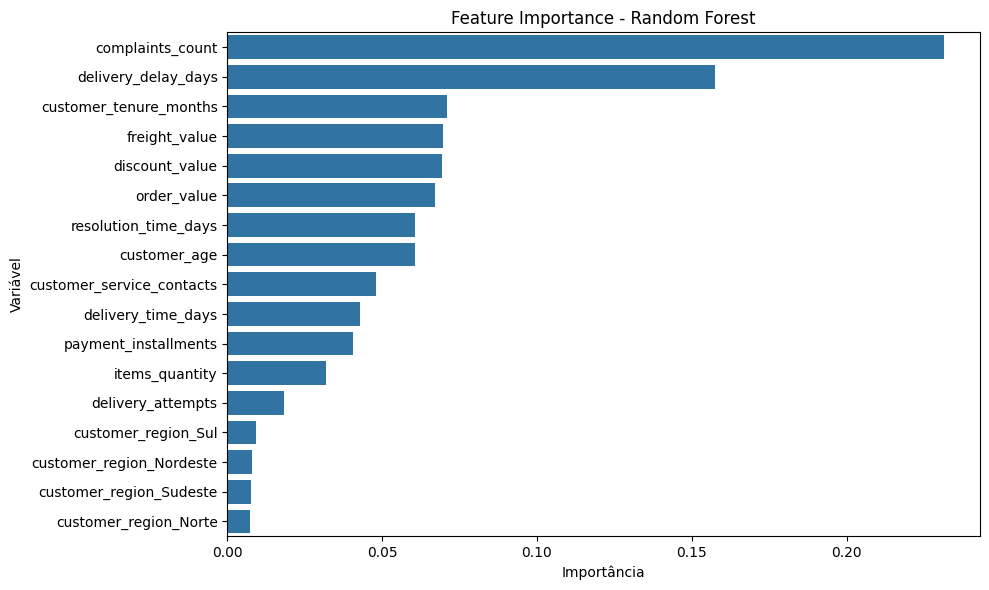

In [374]:
plt.figure(figsize=(10, 6))
sns.barplot(data=importancias, x='importancia', y='feature')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importância')
plt.ylabel('Variável')
plt.tight_layout()
plt.show()

### **Insights importantes**

**1. Confirmação da EDA**  
As duas variáveis mais importantes do modelo são exatamente as duas com maior correlação que identificamos no EDA — complaints_count (0.45) e delivery_delay_days (0.40). O modelo aprendeu o que a análise já sugeria.


**2. Surpresas do modelo**  
freight_value e order_value aparecem com importância razoável (~7%), mas na EDA os boxplots mostravam pouca diferença entre grupos. Isso acontece porque o Random Forest captura relações não-lineares que o boxplot não mostra.



**3. Região confirmada como irrelevante**  
As 4 variáveis de região ficaram no final, confirma a conclusão da análise regional da Questão 3.


### **Por que Random Forest é melhor que a Regressão Logística nesse caso?**

| | Regressão Logística | Random Forest |
|---|---|---|
| Relações entre variáveis | Só lineares | Lineares e não-lineares |
| Desbalanceamento | Precisa de `class_weight` | Lida melhor naturalmente |
| Interpretabilidade | Alta | Média |
| Performance geral | Boa baseline | Geralmente superior |

**Parametros principais**

n_estimators → quantas árvores criar. Mais árvores = mais robusto, mas mais lento. Padrão: 100.    

class_weight='balanced' → mesmo que na Regressão Logística — compensa o desbalanceamento.    

random_state=42 → reprodutibilidade.  

### **Comparação Regressão Logística vs Random Forest**

| Métrica | Meta | Regressão Logística | Random Forest | Melhor |
|---|---|---|---|---|
| Recall | ≥ 75% | 81% | 95% | 🏆 Random Forest |
| AUC-ROC | ≥ 0.80 | 87% | 85% | 🏆 Regressão Logística |
| F1-Score | ≥ 0.70 | 86% | 88% | 🏆 Random Forest |
| Precision | ≥ 60% | 91% | 82% | 🏆 Regressão Logística |


**O que isso significa?**  
Random Forest ganhou no Recall, captura 95% dos Detratores reais vs 81% da Regressão Logística.   
Para o objetivo de negócio, isso é o mais importante.  

Regressão Logística ganhou na Precision, 91% vs 82%. O Random Forest gera mais falsos positivos. Mas para o negócio é mais importante gerar falsos positivos que deixar Detratores escaparem e avaliarem uma nota baixa no nps.

Classe 0 - Não Detrator piorou no Random Forest

Recall caiu de 79% para 47%, o modelo está errando mais nos Não Detratores.  
Isso é esperado, ao aumentar o Recall dos Detratores, o modelo classifica mais clientes como Detrator.  

### **Modelo de Classificação escolhido: Random Forest**

O modelo selecionado para produção é o Random Forest. A métrica prioritária definida na fase 1 é o Recall: Capturar o máximo de Detratores possível antes que avaliem negativamente a empresa. O Random Forest atingiu Recall de 95% vs 81% da Regressão Logística, identificando 14 Detratores a mais a cada 100 casos reais.  

Embora a Precision tenha caído de 91% para 82%, o custo de acionar preventivamente um cliente satisfeito é baixo comparado ao custo de deixar um Detrator sem ação, conforme documentado na fase 1.  

Todas as metas técnicas foram atingidas por ambos os modelos, mas o Random Forest se alinha melhor ao objetivo de negócio de maximizar a captura de insatisfeitos.


## **Modelo de regressão - Regressão Linear**

No modelo de regressão vamos prever a nota do NPS, uma variável numérica de 0 a 10.  
O algoritmo mais adequado para isso é a Regressão Linear, ele tenta encontrar a melhor linha que representa a relação entre as features e o nps_score.  

Começaremos com esse modelo simples como baseline, posteriormente vamos comparar com o Random Forest Regressor e compararemos os resultados. 

| Métrica | O que mede |
|---|---|
| **MAE** | Erro médio absoluto em pontos de NPS |
| **RMSE** | Erro quadrático médio — penaliza erros grandes |
| **R²** | Quanto o modelo explica a variação do NPS |

In [375]:
# Libraries 

import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np

# Loading .csv
# Creating Target variable 

df = pd.read_csv("desafio_nps_fase_1.csv")

df.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


### Removendo variáveis

Removendo variáveis sem relevância e as proibidas por leakage (csat_internal_score, repeat_purchase_30d). 


In [376]:
colunas_remover = ['customer_id', 'order_id', 'csat_internal_score', 'repeat_purchase_30d']

df = df.drop(colunas_remover, axis=1)
df.head()

,customer_age,customer_region,customer_tenure_months,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,complaints_count
0,63,Nordeste,14,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,3
1,20,Sul,1,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,3
2,46,Nordeste,111,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,7
3,52,Centro-Oeste,117,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,4
4,56,Norte,50,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,3


### Tratando variáveis categóricas

O modelo de Machine Learning não entende texto como "Sudeste" ou "Sul". Precisamos transformar essa variável em números com **One-Hot Enconding**.

In [377]:
df = pd.get_dummies(df, columns=['customer_region'], drop_first=True)

df.columns

Index(['customer_age', 'customer_tenure_months', 'order_value',
       'items_quantity', 'discount_value', 'payment_installments',
       'delivery_time_days', 'delivery_delay_days', 'freight_value',
       'delivery_attempts', 'customer_service_contacts',
       'resolution_time_days', 'nps_score', 'complaints_count',
       'customer_region_Nordeste', 'customer_region_Norte',
       'customer_region_Sudeste', 'customer_region_Sul'],
      dtype='str')

In [378]:
df.head()

,customer_age,customer_tenure_months,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,complaints_count,customer_region_Nordeste,customer_region_Norte,customer_region_Sudeste,customer_region_Sul
0,63,14,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,3,True,False,False,False
1,20,1,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,3,False,False,False,True
2,46,111,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,7,True,False,False,False
3,52,117,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,4,False,False,False,False
4,56,50,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,3,False,True,False,False


### Separando Features e Target

X → todas as colunas que o modelo vai usar para aprender (features)  
y → a coluna que o modelo vai prever (target)  

Features (x) = Todas as colunas menos nps_score (target) do dataframe. 

Target (y) = nps_score 


In [379]:
X = df.drop(columns=["nps_score"])
y = df["nps_score"]

print(X.shape)
print(y.shape)

(2500, 17)
(2500,)


### Dividindo Dataset em Treino e Teste 

Precisamos dividir nossos dados em dois grupos: 

Treino → o modelo aprende com esses dados  
Teste → o modelo é avaliado com dados que nunca viu

In [380]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)

(2000, 17)
(500, 17)


Treino → 2000 linhas (80% dos dados): O modelo aprende com isso  

Teste → 500 linhas (20% dos dados): O modelo será avaliado com isso

A proporção 80/20 é a mais comum em datasets de tamanho médio, garante dados suficientes para treino sem comprometer a avaliação.  
 
O random_state= 42 garante reprodutibilidade, ou seja, a divisão será sempre a mesma em qualquer execução.

In [381]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Treinando o modelo
modelo_regressao = LinearRegression()
modelo_regressao.fit(X_train, y_train)

# Previsões
y_pred = modelo_regressao.predict(X_test)


### Métricas MAE, RMSE e R²

| Métrica | Sigla em inglês | Tradução | O que mede |
|---|---|---|---|
| **MAE** | Mean Absolute Error | Erro Médio Absoluto | Erro médio em pontos de NPS: Fácil de interpretar, mesma escala do target |
| **RMSE** | Root Mean Squared Error | Raiz do Erro Quadrático Médio | Penaliza erros grandes: Útil para detectar previsões muito erradas |
| **R²** | R-Squared | Coeficiente de Determinação | % da variação do NPS que o modelo consegue explicar |

In [382]:
# Erro médio absoluto
mae = mean_absolute_error(y_test, y_pred)
print(f"MAE: {mae:.4f}")

MAE: 1.3352


MAE — Erro Médio Absoluto

MAE = 1.33 → o modelo previu 6.0 mas o cliente deu 7.33 ou previu 8.0 mas o cliente deu 6.67  

Está na mesma escala que o NPS (0 a 10).

In [383]:
# Raiz do Erro Quadrático Médio
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE: {rmse:.4f}")

RMSE: 1.6899


RMSE — Raiz do Erro Quadrático Médio

RMSE = 1.69 → Maior que o MAE (1.33) porque alguns clientes o modelo errou muito, por exemplo, previu 8 mas o cliente deu 3

Se RMSE for muito maior que MAE → Modelo tem casos onde erra feio.  

Como a diferença é pequena (1.33 vs 1.69), modelo razoavelmente consistente.  

In [384]:
# Coeficiente de Determinação 
r2 = r2_score(y_test, y_pred)
print(f"R²: {r2:.4f}")

R²: 0.5481


R² — Coeficiente de Determinação

Quanto % da variação do NPS o modelo consegue explicar?

R² = 0.54 → de cada 10 pontos de variação no NPS, o modelo explica 5.4 e os outros 4.6 são fatores que o dataset não captura (humor do cliente, expectativas pessoais, etc.)

| R² | Interpretação |
|---|---|
| < 0.30 | Modelo fraco |
| 0.30 - 0.50 | Modelo razoável |
| 0.50 - 0.70 | Modelo moderado |
| 0.70 - 0.90 | Modelo bom |
| 0.90 - 1.00 | Modelo excelente |
| 1.00 | Leakage — impossível na prática |

O modelo captura mais da metade da variação do NPS, mas há espaço para melhorar. 

| Métrica | Resultado | Interpretação |
|---|---|---|
| **MAE** | 1.33 | Em média o modelo erra 1.33 pontos na nota NPS |
| **RMSE** | 1.69 | Erros grandes existem mas são controlados |
| **R²** | 0.54 | O modelo explica 54% da variação do NPS |

Para demonstrar o modelo em produção, simulamos uma previsão da nota NPS para o primeiro cliente do conjunto de teste. Na prática, o modelo receberia os dados operacionais do cliente assim que a entrega fosse concluída e retornaria a nota estimada, permitindo antecipar se o cliente está em risco de ser Detrator.

In [385]:
primeiro_cliente = X_test.iloc[[0]]
previsao_nota = modelo_regressao.predict(primeiro_cliente)
print(f"Nota NPS prevista: {previsao_nota[0]:.2f}")

Nota NPS prevista: 5.41


Se a nota prevista for ≤ 6, o cliente está em risco de ser Detrator. Mesmo sem usar o modelo de classificação, a nota estimada já permite uma triagem inicial.

### **Cross-Validation**

Para garantir que o modelo não está apenas se saindo bem em um split específico, aplicamos Cross-Validation com 5 folds. O modelo é treinado e testado 5 vezes em partes diferentes dos dados.

In [386]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
import pandas as pd

# Recriando o modelo para o Cross-Validation
modelo_lr_cv = LinearRegression()

scores = cross_val_score(modelo_lr_cv, X_train, y_train, cv=5, scoring='r2')
print(f"R² médio (CV=5): {scores.mean():.2f} ± {scores.std():.2f}")

R² médio (CV=5): 0.55 ± 0.04


O Cross-Validation com 5 folds confirma a estabilidade do modelo. Em 5 avaliações diferentes, a Regressão Linear manteve R² médio de 0.55 com variação de ±0.04, consistente com o resultado de 0.54 obtido no conjunto de teste.
Isso confirma que o modelo não está sofrendo de overfitting, explica aproximadamente 55% da variação do NPS de forma estável.

| Cross-Validation | Resultado |
|---|---|
| R² médio (CV=5) | 0.55 |
| Desvio padrão | ± 0.04 |
| Interpretação | Modelo estável — resultado consistente com o conjunto de teste |

## **Modelo de regressão - Random Forest**




A Regressão Linear assumiu que a relação entre as features e o nps_score é linear, ou seja, que cada variável contribui de forma proporcional e constante para a nota. Essa é uma limitação importante.

O Random Forest Regressor resolve isso, assim como o Random Forest no modelo de classificação, ele cria centenas de árvores de decisão e combina as previsões, capturando relações não-lineares entre as variáveis.

Esperamos que o R² seja superior ao da Regressão Linear (0.54) e o MAE inferior (1.33), confirmando que relações não-lineares existem no dataset e que o modelo mais robusto consegue capturá-las melhor.

As métricas de avaliação permanecem as mesmas: MAE, RMSE e R².

In [387]:
# Algoritmo do modelo
from sklearn.ensemble import RandomForestRegressor
# Métricas
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
#Library 
import numpy as np

df.head()


,customer_age,customer_tenure_months,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,complaints_count,customer_region_Nordeste,customer_region_Norte,customer_region_Sudeste,customer_region_Sul
0,63,14,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,3,True,False,False,False
1,20,1,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,3,False,False,False,True
2,46,111,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,7,True,False,False,False
3,52,117,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,4,False,False,False,False
4,56,50,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,3,False,True,False,False


In [388]:
# 2. Treinando o Modelo (Fit)
# O Target é a coluna 'nps_score'
# random_state=42 → garante reprodutibilidade
modelo = RandomForestRegressor(random_state= 42)

# fit → o modelo aprende os padrões dos dados de treino
# Random Forest cria árvores de decisão em amostras aleatórias com os dados de treino
modelo.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [389]:
# 3. Gerar Previsões
y_pred = modelo.predict(X_test)


In [390]:
# 4. Calculando métricas 
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)


In [391]:
# 5. Exibir Métricas de Regressão

print(f"MAE: {mae:.4f}")

MAE: 1.4026


Em média o modelo erra 1.40 pontos na previsão da nota NPS. Levemente superior ao da Regressão Linear (1.33), o Random Forest errou mais em média.

In [392]:
print(f"RMSE: {rmse:.4f}")

RMSE: 1.7546


O erro quadrático médio de 1.75 é maior que o MAE (1.40), indicando que existem alguns casos onde o modelo errou bastante. Também superior ao da Regressão Linear (1.69).

In [393]:
print(f"R²: {r2:.4f}")

R²: 0.5128


O modelo explica 51% da variação do NPS, inferior à Regressão Linear (54%). O Random Forest não conseguiu capturar padrões adicionais além do que a Regressão Linear já identificava.

| Métrica | Resultado | Interpretação |
|---|---|---|
| **MAE** | 1.40 | Em média o modelo erra 1.40 pontos na nota NPS |
| **RMSE** | 1.75 | Erros grandes existem e são ligeiramente maiores que na Regressão Linear |
| **R²** | 0.51 | O modelo explica 51% da variação do NPS |

### **Cross-Validation**

Para garantir que o modelo não está apenas se saindo bem em um split específico, aplicamos Cross-Validation com 5 folds. O modelo é treinado e testado 5 vezes em partes diferentes dos dados.

In [394]:
scores = cross_val_score(modelo, X_train, y_train, cv=5, scoring='r2')
print(f"R² médio (CV=5): {scores.mean():.2f} ± {scores.std():.2f}")

R² médio (CV=5): 0.52 ± 0.04


O R² médio de 0.52 com desvio padrão de ±0.04 confirma que o modelo explica consistentemente cerca de 52% da variação do NPS em diferentes subsets dos dados. A baixa variação (±0.04) indica estabilidade, o modelo não é dependente de um split específico.

| Cross-Validation | Resultado |
|---|---|
| R² médio (CV=5) | 0.52 |
| Desvio padrão | ± 0.04 |
| Interpretação | Modelo estável e consistente entre os folds |

### **Comparação Regressão Linear vs Random Forest**

| Métrica | Regressão Linear | Random Forest Regressor | Melhor |
|---|---|---|---|
| MAE | 1.3352 | 1.4026 | 🏆 Regressão Linear |
| RMSE | 1.6899 | 1.7546 | 🏆 Regressão Linear |
| R² | 0.5481 | 0.5128 | 🏆 Regressão Linear |


**O que isso significa?**  

A Regressão Linear superou o Random Forest Regressor em todas as métricas, sendo mais simples e mais eficaz para esse dataset. Isso indica que as relações entre as features e o nps_score são predominantemente lineares.

**Razões principais**  

- Dataset pequeno: Apenas 2500 linhas é pouco para o Random Forest capturar padrões complexos  
- nps_score é float contínuo: O Random Forest funciona melhor com targets mais discretos  
- Relações são predominantemente lineares: A Regressão Linear já captura bem o padrão existente  



### **Modelo de regressão escolhido: Regressão Linear**

Para prever a nota do NPS nesse dataset, a Regressão Linear é suficiente e preferível: É mais simples, mais interpretável e mais eficaz. O Random Forest não agregou valor adicional.

### **Comparação final entre os 4 modelos**

| Modelo | Métrica principal | Resultado (teste) | CV médio | Desvio |
|---|---|---|---|---|
| Regressão Logística | Recall | 81% | 79% | ±0.02 |
| Random Forest Clf | Recall | 95% | 94% | ±0.01 |
| Regressão Linear | R² | 0.54 | 0.55 | ±0.04 |
| Random Forest Reg | R² | 0.51 | 0.52 | ±0.04 |


Essa tabela consolida os resultados de todos os modelos treinados, comparando a performance no conjunto de teste com a validação cruzada (CV=5). O Cross-Validation confirma que nenhum modelo está sofrendo de overfitting, os resultados são consistentes entre o teste e a validação.

Para os modelos de classificação, o Random Forest se destaca com Recall de 95% no teste e 94% no CV, confirmando sua superioridade e estabilidade para identificar Detratores.

Para os modelos de regressão, a Regressão Linear supera o Random Forest Regressor em todas as métricas, com R² de 0.54 no teste e 0.55 no CV, indicando que as relações entre as features e o nps_score são predominantemente lineares nesse dataset.

**Os modelos escolhidos para produção são: Random Forest para classificação e Regressão Linear para regressão.**